<a href="https://colab.research.google.com/github/natthamonsmn/Cinema_Team/blob/main/Cinema.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🍿🎥✮⋆˙ ธุรกิจโรงภาพยนตร์ (Cinema)
เน้น **ระบบจองที่นั่งดูหนัง** เช่น การจองที่นั่งของลูกค้า, ตรวจสอบที่นั่งว่าง, คำนวณราคาตามประเภทที่นั่งและประเภทสมาชิก

## 1. โครงสร้างโปรแกรม

## ส่วนที่ 1 — เตรียม class และฟังก์ชัน

In [1]:
from datetime import datetime, timedelta
import random
import pandas as pd
import numpy as np
import os, shutil
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

In [2]:
!pip install Faker
from faker import Faker #สุ่มชื่อภาษาไทยสมจริงอัตโนมัติ
fake = Faker("th_TH")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 8.2 MB/s eta 0:00:00


In [3]:
# 1. ติดตั้งฟอนต์ภาษาไทย
!apt-get -y install fonts-thai-tlwg

# 2. ล้าง cache ของ matplotlib เพื่ออัปเดตฟอนต์ใหม่
cache_dir = matplotlib.get_cachedir()
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)

# 3. ลงทะเบียนฟอนต์ใหม่เข้ากับ FontManager
font_path = '/usr/share/fonts/truetype/tlwg/Loma.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)

# 4. ตั้งค่าฟอนต์หลัก
plt.rcParams['font.family'] = 'Loma'
plt.rcParams['axes.unicode_minus'] = False

# 5. สร้างข้อมูลจำลองและแสดงผล
data = {
    'เมือง': ['กรุงเทพฯ', 'เชียงใหม่', 'ภูเก็ต'],
    'อุณหภูมิ': [30.5, 25.2, 28.9]
}

df_thai = pd.DataFrame(data)

print("ตั้งค่าระบบฟอนต์ภาษาไทยสำเร็จ!")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-tlwg-garuda fonts-tlwg-garuda-ttf fonts-tlwg-kinnari
  fonts-tlwg-kinnari-ttf fonts-tlwg-laksaman fonts-tlwg-laksaman-ttf
  fonts-tlwg-loma fonts-tlwg-loma-ttf fonts-tlwg-mono fonts-tlwg-mono-ttf
  fonts-tlwg-norasi fonts-tlwg-norasi-ttf fonts-tlwg-purisa
  fonts-tlwg-purisa-ttf fonts-tlwg-sawasdee fonts-tlwg-sawasdee-ttf
  fonts-tlwg-typewriter fonts-tlwg-typewriter-ttf fonts-tlwg-typist
  fonts-tlwg-typist-ttf fonts-tlwg-typo fonts-tlwg-typo-ttf fonts-tlwg-umpush
  fonts-tlwg-umpush-ttf fonts-tlwg-waree fonts-tlwg-waree-ttf
The following NEW packages will be installed:
  fonts-thai-tlwg fonts-tlwg-garuda fonts-tlwg-garuda-ttf fonts-tlwg-kinnari
  fonts-tlwg-kinnari-ttf fonts-tlwg-laksaman fonts-tlwg-laksaman-ttf
  fonts-tlwg-loma fonts-tlwg-loma-ttf fonts-tlwg-mono fonts-tlwg-mono-ttf
  fonts-tlwg-norasi fonts-tlwg-norasi-ttf fo

**Class** ของระบบการจองตั๋วโรงภาพยนตร์ ประกอบด้วย 3 class ดังนี้ :

| Class | Object | Attributes | Methods / Functions | |
|---|---|---|---|---|
| `Customer` | เก็บข้อมูลของผู้ใช้งานและสิทธิ์ส่วนลด | รหัสลูกค้า, ชื่อ-นามสกุล, ระดับสมาชิก, แต้มสะสม|  ตรวจสอบสิทธิ์ส่วนลดตามระดับสมาชิก, สะสมแต้มจากการจองสำเร็จ |
| `Showtime` | เก็บข้อมูลหนัง วันเวลาที่ฉาย และราคาพื้นฐาน|  รหัสรอบฉาย, ชื่อภาพยนตร์, หมายเลขโรงภาพยนตร์ , วันและเวลาที่ฉาย, ราคาพื้นฐานของรอบฉาย| ตรวจสอบไม่ให้โรงหนังเดียวกันมีรอบฉายเวลาชนกัน |
| `Booking` |  เชื่อมระหว่าง "ลูกค้า" และ "รอบฉาย" เพื่อบันทึกรายละเอียดการจอง | รหัสการจอง, รหัสลูกค้า, รหัสรอบฉาย, เลขที่นั่ง, ประเภทที่นั่ง, ราคาสุทธิ, สถานะการจอง| คำนวณราคาสุทธิ, ตรวจสอบว่าที่นั่งในรอบนั้นยังว่างอยู่หรือไม่, ยืนยันและบันทึกการจองลงระบบ |

In [4]:
class Customer:
    def __init__(self, customer_id, name, member_type="General"):
        self.customer_id = customer_id
        self.name = name
        self.member_type = member_type
        self.points = 0

    def get_discount_rate(self, promo_discount_rate=0.0):
        member_discounts = {"General": 0.0, "Student": 0.20, "VIP": 0.30}
        member_rate = member_discounts.get(self.member_type, 0.0)
        return max(member_rate, promo_discount_rate)

    def add_points(self, net_price):
        earned = int(net_price // 10)
        self.points += earned
        return earned


class Showtime:
    def __init__(self, showtime_id, movie_name, theater_no, start_time, end_time, base_price):
        self.showtime_id = showtime_id
        self.movie_name = movie_name
        self.theater_no = theater_no
        self.start_time = start_time
        self.end_time = end_time
        self.base_price = base_price


class Booking:
    def __init__(self, booking_id, customer, showtime, seat_number, seat_type):
        self.booking_id = booking_id
        self.customer = customer
        self.showtime = showtime
        self.seat_number = seat_number.upper()
        self.seat_type = seat_type
        self.booking_time = datetime.now()
        self.status = "Pending"
        # เรียกใช้ Helper Function คิดราคา
        self.net_price = calculate_booking_price(showtime.base_price, seat_type, customer.member_type)

    def check_timeout(self):
        if self.status == "Pending":
            if datetime.now() > self.booking_time + timedelta(minutes=10):
                self.status = "Cancelled"
                return True
        return False

    def confirm_payment(self):
        if self.check_timeout():
            raise Exception("เกินเวลา 10 นาที (Timeout Auto-Cancel)")
        self.status = "Paid"
        self.customer.add_points(self.net_price)
        return self.net_price

## ฟังก์ชันช่วยงาน (Helper Function)

In [5]:
def calculate_booking_price(base_price, seat_type="Normal", member_type="General", promo_discount=0.0):
    """ฟังก์ชันที่ 1: คำนวณราคาสุทธิ (มี Default Argument)"""
    seat_extras = {"Normal": 0, "Deluxe": 40, "Honeymoon": 80, "VIP": 190}
    member_discounts = {"General": 0.0, "Student": 0.20, "VIP": 0.30}

    total_seat_price = base_price + seat_extras.get(seat_type, 0)
    best_discount = max(member_discounts.get(member_type, 0.0), promo_discount)
    return round(total_seat_price * (1 - best_discount), 2)


def validate_seat_booking(seat_number, existing_seats_list, valid_seat_range=None):
    """ฟังก์ชันที่ 2: ตรวจสอบผังและที่นั่งซ้ำ (มี Default Argument)"""
    if valid_seat_range is None:
        valid_seat_range = [f"{row}{num}" for row in "ABCDEF" for num in range(1, 11)]

    seat_upper = seat_number.upper()
    if seat_upper not in valid_seat_range:
        return False, f"ที่นั่ง {seat_number} ไม่มีอยู่ในระบบ (Invalid Seat)"
    if seat_upper in existing_seats_list:
        return False, f"ที่นั่ง {seat_number} ถูกจองแล้ว (Double Booking)"
    return True, "ที่นั่งว่าง สามารถจองได้"


def process_ticket_scan(ticket_id, current_status="Paid", auto_update=True):
    """ฟังก์ชันที่ 3: จำลองการสแกน QR Code เข้าโรง (มี Default Argument)"""
    if current_status == "Used":
        return False, f"ตั๋ว {ticket_id} ถูกใช้งานไปแล้ว ไม่สามารถสแกนซ้ำได้!"
    elif current_status != "Paid":
        return False, f"ตั๋ว {ticket_id} ยังไม่ได้ชำระเงิน"

    new_status = "Used" if auto_update else current_status
    return True, f"สแกนสำเร็จ! ({new_status})"

def mask_lastname_only(fullname):
    parts = fullname.split()
    if len(parts) >= 2:
        first_name, last_name = parts[0], parts[1]
        # ชื่อจริงเต็ม + อักษรแรกนามสกุล แล้วตามด้วย ***
        return f"{first_name} {last_name[0]}***"
    return fullname

## จำลอง 300 รายการทีละคน

In [6]:
# Execution Simulation Loop (จำลอง 300 รายการทีละคน)
showtime_1 = Showtime(
    "ST01",
    "Avatar 3",
    1,
    datetime(2026, 8, 20, 14, 0),
    datetime(2026, 8, 20, 17, 0),
    160,
)
showtime_2 = Showtime(
    "ST02",
    "Spider-Man",
    2,
    datetime(2026, 8, 20, 15, 30),
    datetime(2026, 8, 20, 18, 0),
    180,
)
showtime_3 = Showtime(
    "ST03",
    "Batman",
    3,
    datetime(2026, 8, 20, 19, 0),
    datetime(2026, 8, 20, 22, 0),
    200,
)

showtime_4 = Showtime(
    "ST04",
    "Inception",
    4,
    datetime(2026, 8, 20, 13, 0),
    datetime(2026, 8, 20, 15, 30),
    170,
)
showtime_5 = Showtime(
    "ST05",
    "Interstellar",
    5,
    datetime(2026, 8, 20, 20, 0),
    datetime(2026, 8, 20, 23, 0),
    190,
)

showtimes_pool = [
    showtime_1,
    showtime_2,
    showtime_3,
    showtime_4,
    showtime_5,
]

# ป้องกันการจองซ้ำ
booked_seats_by_theater = {1: [], 2: [], 3: [], 4: [], 5: []}

all_bookings = []
member_pool = ["General", "Student", "VIP"]
seat_type_pool = ["Normal", "Deluxe", "Honeymoon", "VIP"]
seat_pool = [f"{r}{n}" for r in "ABCDEF" for n in range(1, 11)] + ["Z99"]

# Loop จำลอง 300 รายการ (สุ่มเลือกโรงภาพยนตร์)
first_names = [
    "สมชาย",
    "วิภา",
    "กิตติ",
    "อนันต์",
    "นภา",
    "กมล",
    "ธนกฤต",
    "ศิริพร",
    "ชลธิชา",
    "ณัฐพงษ์",
]
last_names = [
    "ใจดี",
    "รักสงบ",
    "เจริญสุข",
    "มีมาก",
    "มั่นคง",
    "วงศ์สวัสดิ์",
    "สมบูรณ์",
    "สุวรรณ",
]

for i in range(1, 301):
    cust_id = f"C{i:03d}"
    cust_name = f"{random.choice(first_names)} {random.choice(last_names)}"

    chosen_member = random.choice(member_pool)
    chosen_seat = random.choice(seat_pool)
    chosen_seat_type = random.choice(seat_type_pool)
    booking_id = f"BK{i:03d}"

    # สุ่มเลือกโรงภาพยนตร์ 1 จาก 3 โรง
    chosen_showtime = random.choice(showtimes_pool)
    theater_no = chosen_showtime.theater_no

    customer = Customer(cust_id, cust_name, chosen_member)

    # ตรวจสอบที่นั่งซ้ำเฉพาะในโรงภาพยนตร์ที่เลือก
    is_valid, seat_msg = validate_seat_booking(
        chosen_seat, booked_seats_by_theater[theater_no]
    )

    if not is_valid:
        failed_booking = Booking(
            booking_id,
            customer,
            chosen_showtime,
            chosen_seat,
            chosen_seat_type,
        )
        failed_booking.status = f"Rejected ({seat_msg})"
        failed_booking.net_price = 0.0
        all_bookings.append(failed_booking)
        continue

    try:
        new_booking = Booking(
            booking_id,
            customer,
            chosen_showtime,
            chosen_seat,
            chosen_seat_type,
        )

        if random.random() < 0.10:
            new_booking.booking_time = datetime.now() - timedelta(minutes=15)

        new_booking.confirm_payment()
        booked_seats_by_theater[theater_no].append(chosen_seat)
        all_bookings.append(new_booking)

    except Exception:
        new_booking.net_price = 0.0
        all_bookings.append(new_booking)

## ส่วนที่ 2 — ทดสอบฟังก์ชันทีละตัว

In [7]:
seat_pool = [f"{r}{n}" for r in "ABCDEF" for n in range(1, 11)]
# ทดสอบเรียกสุ่มที่นั่ง 3 ครั้ง ดูว่าฟังก์ชันสุ่มทำงานได้ค่าไม่ซ้ำกันในแต่ละรอบ
for _ in range(3):
    print("ที่นั่งที่สุ่มได้:", random.choice(seat_pool))

ที่นั่งที่สุ่มได้: A5
ที่นั่งที่สุ่มได้: B5
ที่นั่งที่สุ่มได้: A7


In [8]:
booked_test_list = ["A1"]

# ทดสอบการตรวจที่นั่ง (ที่นั่งซ้ำ, ที่นั่งว่าง, ที่นั่งไม่มีอยู่จริง)
for seat_to_check in ["A1", "B5", "Z99"]:
    is_valid, message = validate_seat_booking(seat_to_check, booked_test_list)
    print(f"ผลการตรวจที่นั่ง '{seat_to_check}':", message)

ผลการตรวจที่นั่ง 'A1': ที่นั่ง A1 ถูกจองแล้ว (Double Booking)
ผลการตรวจที่นั่ง 'B5': ที่นั่งว่าง สามารถจองได้
ผลการตรวจที่นั่ง 'Z99': ที่นั่ง Z99 ไม่มีอยู่ในระบบ (Invalid Seat)


In [9]:
# เปรียบเทียบการเรียก calculate_booking_price() แบบไม่ระบุค่า (ใช้ default) กับแบบระบุช่วงเอง
print("เรียกแบบ default (ไม่ใส่ argument):", calculate_booking_price(160))
print(
    "เรียกแบบระบุช่วงเอง (ที่นั่ง VIP, สมาชิก VIP):",
    calculate_booking_price(160, "VIP", "VIP"),
)
print(
    "เรียกแบบระบุแค่ promo_discount (keyword argument):",
    calculate_booking_price(160, promo_discount=0.50),
)

เรียกแบบ default (ไม่ใส่ argument): 160.0
เรียกแบบระบุช่วงเอง (ที่นั่ง VIP, สมาชิก VIP): 245.0
เรียกแบบระบุแค่ promo_discount (keyword argument): 80.0


## ส่วนที่ 3 — ฟังก์ชันอธิบายขั้นตอนคำนวณราคา

In [10]:
def explain_booking_price(booking):
    """รับ object Booking 1 ตัว -> พิมพ์อธิบายการคำนวณราคาทีละขั้นตอน"""
    seat_extras = {"Normal": 0, "Deluxe": 40, "Honeymoon": 80, "VIP": 190}

    extra_price = seat_extras.get(booking.seat_type, 0)
    base_price = booking.showtime.base_price
    full_price = base_price + extra_price

    discount_rate = booking.customer.get_discount_rate()

    final_price = booking.net_price

    print(
        f"ราคาตั๋วภาพยนตร์เรื่อง '{booking.showtime.movie_name}' (โรง"
        f" {booking.showtime.theater_no}) = {base_price} บาท"
    )
    print(
        f"บวกเพิ่มที่นั่งประเภท '{booking.seat_type}' = +{extra_price} บาท"
        f" (ราคารวมก่อนส่วนลด = {full_price} บาท)"
    )

    if discount_rate > 0:
        print(
            f"ลูกค้าเป็นสมาชิก {booking.customer.member_type} -> ได้ส่วนลด"
            f" {discount_rate * 100:.0f}%"
        )
    else:
        print("ลูกค้าเป็นสมาชิก General -> ไม่มีส่วนลด")

    print(f"ราคาสุทธิ = {final_price:,.2f} บาท")
    return


demo_cust = Customer(
    "C001",
    f"{random.choice(first_names)} {random.choice(last_names)}",
    "VIP",
)

demo_show = Showtime(
    "ST01",
    "Avatar 3",
    1,
    datetime(2026, 8, 20, 18, 0),
    datetime(2026, 8, 20, 21, 0),
    160,
)

demo_booking = Booking("BK001", demo_cust, demo_show, "A1", "Honeymoon")
explain_booking_price(demo_booking)

ราคาตั๋วภาพยนตร์เรื่อง 'Avatar 3' (โรง 1) = 160 บาท
บวกเพิ่มที่นั่งประเภท 'Honeymoon' = +80 บาท (ราคารวมก่อนส่วนลด = 240 บาท)
ลูกค้าเป็นสมาชิก VIP -> ได้ส่วนลด 30%
ราคาสุทธิ = 168.00 บาท


## ตารางบันทึกข้อมูลที่จำลองได้

In [11]:
# ตารางที่ 1 ตารางลูกค้า
customers_rows = [
    {
        "customer_id": b.customer.customer_id,
        "name": (
            f"{b.customer.name.split()[0]} {b.customer.name.split()[1][0]}***"
            if " " in b.customer.name
            else b.customer.name
        ),
        "member_type": b.customer.member_type,
    }
    for b in all_bookings
]

customers_df = pd.DataFrame(customers_rows).drop_duplicates(
    subset=["customer_id"]
)
customers_df.head()

,customer_id,name,member_type
0,C001,ศิริพร ใ***,General
1,C002,สมชาย ว***,Student
2,C003,กิตติ ส***,Student
3,C004,กิตติ ส***,VIP
4,C005,อนันต์ เ***,VIP


In [12]:
# แปลงเป็น CSV
customers_df.to_csv("customers.csv", index=False, encoding="utf-8-sig")

In [13]:
# ตารางที่ 2 ตารางธุรกรรมการจอง
bookings_rows = [
    {
        "booking_id": b.booking_id,
        "customer_id": b.customer.customer_id,  # ใช้เป็น Foreign Key
        "movie_name": b.showtime.movie_name,
        "theater_no": b.showtime.theater_no,
        "seat_number": b.seat_number,
        "seat_type": b.seat_type,
        "price": b.net_price,
        "status": b.status,
    }
    for b in all_bookings
]

bookings_df = pd.DataFrame(bookings_rows)
bookings_df.head()

,booking_id,customer_id,movie_name,theater_no,seat_number,seat_type,price,status
0,BK001,C001,Spider-Man,2,C8,VIP,370.0,Paid
1,BK002,C002,Inception,4,D4,Honeymoon,200.0,Paid
2,BK003,C003,Interstellar,5,D6,VIP,304.0,Paid
3,BK004,C004,Inception,4,A6,Honeymoon,175.0,Paid
4,BK005,C005,Avatar 3,1,A8,Honeymoon,168.0,Paid


In [14]:
# แปลงเป็น CSV
bookings_df.to_csv("bookings.csv", index=False, encoding="utf-8-sig")

## ฐานข้อมูล SQLite

In [15]:
import sqlite3
import pandas as pd

# 1. อ่านไฟล์ CSV ทั้ง 2 เข้าเป็น DataFrame
df_customers = pd.read_csv("https://raw.githubusercontent.com/natthamonsmn/Cinema_Team/refs/heads/main/customers.csv")
df_bookings = pd.read_csv("https://raw.githubusercontent.com/natthamonsmn/Cinema_Team/refs/heads/main/bookings.csv")

# 2. สร้าง connection สู่ SQLite ในหน่วยความจำชั่วคราว (:memory:)
conn = sqlite3.connect(":memory:")

# 3. นำ DataFrame ทั้ง 2 แปลงเป็นตารางใน SQLite ชั่วคราว
df_customers.to_sql("customers", conn, index=False, if_exists="replace")
df_bookings.to_sql("bookings", conn, index=False, if_exists="replace")

# 4. เขียน SQL JOIN ตาราง
query = """
SELECT
    b.booking_id,
    c.customer_id,
    c.name AS customer_name,
    c.member_type,
    b.movie_name,
    b.theater_no,
    b.seat_number,
    b.seat_type,
    b.price,
    b.status
FROM bookings b
JOIN customers c ON b.customer_id = c.customer_id
"""

# 5. ดึงข้อมูลออกมาเป็น DataFrame
df_joined = pd.read_sql_query(query, conn)

# ปิด connection
conn.close()

# แสดงผลลัพธ์
df_joined.head()

,booking_id,customer_id,customer_name,member_type,movie_name,theater_no,seat_number,seat_type,price,status
0,BK001,C001,ศิริพร ม***,Student,Avatar 3,1,C9,Deluxe,160.0,Paid
1,BK002,C002,อนันต์ ร***,VIP,Inception,4,B7,Honeymoon,0.0,Cancelled
2,BK003,C003,กิตติ ว***,Student,Interstellar,5,C3,Honeymoon,0.0,Cancelled
3,BK004,C004,ศิริพร ส***,Student,Avatar 3,1,B7,Honeymoon,192.0,Paid
4,BK005,C005,ชลธิชา เ***,VIP,Spider-Man,2,D6,Normal,126.0,Paid


In [16]:
# แปลงเป็น CSV
df_joined.to_csv("joined.csv", index=False, encoding="utf-8-sig")

In [17]:
# ตารางฉบับเต็ม (ลูกค้า + ธุรกรรมการจอง)
pd.read_csv("https://raw.githubusercontent.com/natthamonsmn/Cinema_Team/refs/heads/main/joined.csv")

,booking_id,customer_id,customer_name,member_type,movie_name,theater_no,seat_number,seat_type,price,status
0,BK001,C001,ศิริพร ม***,Student,Avatar 3,1,C9,Deluxe,160.0,Paid
1,BK002,C002,อนันต์ ร***,VIP,Inception,4,B7,Honeymoon,0.0,Cancelled
2,BK003,C003,กิตติ ว***,Student,Interstellar,5,C3,Honeymoon,0.0,Cancelled
3,BK004,C004,ศิริพร ส***,Student,Avatar 3,1,B7,Honeymoon,192.0,Paid
4,BK005,C005,ชลธิชา เ***,VIP,Spider-Man,2,D6,Normal,126.0,Paid
...,...,...,...,...,...,...,...,...,...,...
295,BK296,C296,ธนกฤต ส***,Student,Inception,4,D10,Deluxe,168.0,Paid
296,BK297,C297,สมชาย เ***,Student,Interstellar,5,F5,VIP,0.0,Rejected (ที่นั่ง F5 ถูกจองแล้ว (Double Booking))
297,BK298,C298,อนันต์ ส***,Student,Inception,4,F8,Normal,136.0,Paid
298,BK299,C299,กมล ร***,Student,Batman,3,A8,VIP,0.0,Rejected (ที่นั่ง A8 ถูกจองแล้ว (Double Booking))


###ส่วนที่ 4 จำลองลูกค้า 1 คน เดินเข้ามาใช้บริการแบบ step-by-step

In [18]:
def simulate_customer_visit(
    customer,
    showtime,
    seat_number,
    seat_type,
    existing_seats,
    promo_discount=0.0,
):

    print("เริ่มกระบวนการจองตั๋วภาพยนตร์")

    masked_name = (
        f"{customer.name.split()[0]} {customer.name.split()[1][0]}***"
        if " " in customer.name
        else customer.name
    )

    # Step 1 ลูกค้าเข้ามา
    print("\n ลูกค้าเดินเข้ามาจองตั๋ว")
    print(f"รหัสลูกค้า: {customer.customer_id}")
    print(f"ชื่อลูกค้า: {masked_name}")
    print(f"ประเภทสมาชิก: {customer.member_type}")

    # Step 2 เลือกรอบหนัง
    print("\n เลือกรอบภาพยนตร์")
    print(f"ภาพยนตร์: {showtime.movie_name}")
    print(f"โรงภาพยนตร์: {showtime.theater_no}")
    print(f"เวลาเริ่ม: {showtime.start_time}")

    # Step 3 ตรวจสอบที่นั่ง
    print("\n ตรวจสอบที่นั่ง")

    is_valid, seat_msg = validate_seat_booking(seat_number, existing_seats)

    print(seat_msg)

    if not is_valid:
        print("\nไม่สามารถทำรายการจองได้")
        return None

    # Step 4 คำนวณราคา
    print("\n คำนวณราคาตั๋ว")

    seat_extras = {"Normal": 0, "Deluxe": 40, "Honeymoon": 80, "VIP": 190}

    # ราคาปกติ = ราคาตั๋วพื้นฐาน + ค่าเพิ่มประเภทที่นั่ง
    normal_price = showtime.base_price + seat_extras.get(seat_type, 0)

    # ราคาสุทธิหลังหักส่วนลด
    net_price = calculate_booking_price(
        showtime.base_price, seat_type, customer.member_type, promo_discount
    )

    print(f"ประเภทที่นั่ง: {seat_type}")
    print(f"ราคาปกติ: {normal_price} บาท")
    print(f"ราคาสุทธิ: {net_price} บาท")

    # Step 5 สร้าง Booking
    print("\n สร้างรายการจอง")

    booking_id = f"BK{customer.customer_id}"

    booking = Booking(
        booking_id, customer, showtime, seat_number, seat_type
    )

    # ใช้ราคาที่คำนวณจากโปรโมชั่น
    booking.net_price = net_price

    print("สร้างรายการจองสำเร็จ")
    print(f"Booking ID: {booking.booking_id}")
    print(f"สถานะ: {booking.status}")

    # Step 6 ชำระเงิน
    print("\n ลูกค้าชำระเงิน")

    try:
        paid_price = booking.confirm_payment()

        print(f"ชำระเงินสำเร็จ: {paid_price} บาท")
        print(f"สถานะปัจจุบัน: {booking.status}")

        # เพิ่มที่นั่งเข้าไปในรายการที่จองแล้ว
        existing_seats.append(seat_number.upper())

    except Exception as e:
        print(f"ชำระเงินไม่สำเร็จ: {e}")
        return booking

    # Step 7 สะสมคะแนน
    print("\n สะสมคะแนนสมาชิก")
    print(f"คะแนนสะสมปัจจุบัน: {customer.points} คะแนน")

    # Step 8 สแกนตั๋ว
    print("\n สแกนตั๋วเข้าโรงภาพยนตร์")

    success, scan_msg = process_ticket_scan(booking.booking_id, booking.status)

    print(scan_msg)

    # สรุปผล
    print("\nสรุปการใช้บริการ")

    print(f"ลูกค้า: {masked_name}")
    print(f"ภาพยนตร์: {showtime.movie_name}")
    print(f"โรงภาพยนตร์: {showtime.theater_no}")
    print(f"ที่นั่ง: {booking.seat_number}")
    print(f"ประเภทที่นั่ง: {booking.seat_type}")
    print(f"ราคาปกติ: {normal_price} บาท")
    print(f"ราคาสุทธิ: {booking.net_price} บาท")
    print(f"สถานะการจอง: {booking.status}")
    print(f"คะแนนสะสม: {customer.points} คะแนน")

    return booking

In [19]:
customer_1 = Customer(
    customer_id="C001",
    name=f"{random.choice(first_names)} {random.choice(last_names)}",
    member_type="Student",
)

showtime_1 = Showtime(
    "ST01",
    "Avatar 3",
    1,
    datetime(2026, 8, 20, 14, 0),
    datetime(2026, 8, 20, 17, 0),
    160,
)

existing_seats = ["A1", "A2", "B5"]

# รันฟังก์ชันจำลองการจองตั๋ว
booking_result = simulate_customer_visit(
    customer=customer_1,
    showtime=showtime_1,
    seat_number="C3",
    seat_type="Deluxe",
    existing_seats=existing_seats,
    promo_discount=0.10,
)

เริ่มกระบวนการจองตั๋วภาพยนตร์

 ลูกค้าเดินเข้ามาจองตั๋ว
รหัสลูกค้า: C001
ชื่อลูกค้า: ศิริพร เ***
ประเภทสมาชิก: Student

 เลือกรอบภาพยนตร์
ภาพยนตร์: Avatar 3
โรงภาพยนตร์: 1
เวลาเริ่ม: 2026-08-20 14:00:00

 ตรวจสอบที่นั่ง
ที่นั่งว่าง สามารถจองได้

 คำนวณราคาตั๋ว
ประเภทที่นั่ง: Deluxe
ราคาปกติ: 200 บาท
ราคาสุทธิ: 160.0 บาท

 สร้างรายการจอง
สร้างรายการจองสำเร็จ
Booking ID: BKC001
สถานะ: Pending

 ลูกค้าชำระเงิน
ชำระเงินสำเร็จ: 160.0 บาท
สถานะปัจจุบัน: Paid

 สะสมคะแนนสมาชิก
คะแนนสะสมปัจจุบัน: 16 คะแนน

 สแกนตั๋วเข้าโรงภาพยนตร์
สแกนสำเร็จ! (Used)

สรุปการใช้บริการ
ลูกค้า: ศิริพร เ***
ภาพยนตร์: Avatar 3
โรงภาพยนตร์: 1
ที่นั่ง: C3
ประเภทที่นั่ง: Deluxe
ราคาปกติ: 200 บาท
ราคาสุทธิ: 160.0 บาท
สถานะการจอง: Paid
คะแนนสะสม: 16 คะแนน


### ส่วนที่ 5 จำลองลูกค้าหลายคนเข้ามาใช้บริการต่อเนื่องกัน

In [20]:
# 1. สร้างรอบหนังครบทั้ง 5 เรื่อง (5 โรง)
showtime_1 = Showtime(
    "ST01",
    "Avatar 3",
    1,
    datetime(2026, 8, 20, 14, 0),
    datetime(2026, 8, 20, 17, 0),
    160,
)
showtime_2 = Showtime(
    "ST02",
    "Spider-Man",
    2,
    datetime(2026, 8, 20, 15, 30),
    datetime(2026, 8, 20, 18, 0),
    180,
)
showtime_3 = Showtime(
    "ST03",
    "Batman",
    3,
    datetime(2026, 8, 20, 19, 0),
    datetime(2026, 8, 20, 22, 0),
    200,
)
showtime_4 = Showtime(
    "ST04",
    "Inception",
    4,
    datetime(2026, 8, 20, 13, 0),
    datetime(2026, 8, 20, 15, 30),
    170,
)
showtime_5 = Showtime(
    "ST05",
    "Interstellar",
    5,
    datetime(2026, 8, 20, 20, 0),
    datetime(2026, 8, 20, 23, 0),
    190,
)

# รวมรอบหนังทั้ง 5 เรื่องไว้สำหรับสุ่มเลือก
showtimes_pool = [
    showtime_1,
    showtime_2,
    showtime_3,
    showtime_4,
    showtime_5,
]

# เก็บที่นั่งที่ถูกจองแยกตามโรง (รองรับโรง 1 ถึง 5)
booked_seats_by_theater = {1: [], 2: [], 3: [], 4: [], 5: []}

# ข้อมูลสำหรับสุ่ม
member_pool = ["General", "Student", "VIP"]
seat_type_pool = ["Normal", "Deluxe", "Honeymoon", "VIP"]
seat_pool = [
    f"{row}{num}" for row in "ABCDEF" for num in range(1, 11)
] + ["Z99"]

# 2. ลูปสุ่มจำลองลูกค้า
for i in range(1, 6):
    print(f"\nลูกค้าคนที่ {i}")

    # สุ่มข้อมูลต่างๆ
    chosen_member = random.choice(member_pool)
    chosen_showtime = random.choice(showtimes_pool)
    chosen_seat = random.choice(seat_pool)
    chosen_seat_type = random.choice(seat_type_pool)

    # สุ่มชื่อ-นามสกุลจริงให้ลูกค้า
    random_fullname = (
        f"{random.choice(first_names)} {random.choice(last_names)}"
    )

    # สร้าง Object Customer
    customer = Customer(
        customer_id=f"C{i:03d}",
        name=random_fullname,
        member_type=chosen_member,
    )

    # เรียกใช้ฟังก์ชันจำลองการจอง
    booking_result = simulate_customer_visit(
        customer=customer,
        showtime=chosen_showtime,
        seat_number=chosen_seat,
        seat_type=chosen_seat_type,
        # ส่งรายการที่นั่งแยกตามโรงที่เลือก
        existing_seats=booked_seats_by_theater[chosen_showtime.theater_no],
        # สุ่มส่วนลดโปรโมชัน 0% หรือ 10%
        promo_discount=random.choice([0.0, 0.10]),
    )


ลูกค้าคนที่ 1
เริ่มกระบวนการจองตั๋วภาพยนตร์

 ลูกค้าเดินเข้ามาจองตั๋ว
รหัสลูกค้า: C001
ชื่อลูกค้า: ชลธิชา ว***
ประเภทสมาชิก: General

 เลือกรอบภาพยนตร์
ภาพยนตร์: Spider-Man
โรงภาพยนตร์: 2
เวลาเริ่ม: 2026-08-20 15:30:00

 ตรวจสอบที่นั่ง
ที่นั่งว่าง สามารถจองได้

 คำนวณราคาตั๋ว
ประเภทที่นั่ง: VIP
ราคาปกติ: 370 บาท
ราคาสุทธิ: 333.0 บาท

 สร้างรายการจอง
สร้างรายการจองสำเร็จ
Booking ID: BKC001
สถานะ: Pending

 ลูกค้าชำระเงิน
ชำระเงินสำเร็จ: 333.0 บาท
สถานะปัจจุบัน: Paid

 สะสมคะแนนสมาชิก
คะแนนสะสมปัจจุบัน: 33 คะแนน

 สแกนตั๋วเข้าโรงภาพยนตร์
สแกนสำเร็จ! (Used)

สรุปการใช้บริการ
ลูกค้า: ชลธิชา ว***
ภาพยนตร์: Spider-Man
โรงภาพยนตร์: 2
ที่นั่ง: E7
ประเภทที่นั่ง: VIP
ราคาปกติ: 370 บาท
ราคาสุทธิ: 333.0 บาท
สถานะการจอง: Paid
คะแนนสะสม: 33 คะแนน

ลูกค้าคนที่ 2
เริ่มกระบวนการจองตั๋วภาพยนตร์

 ลูกค้าเดินเข้ามาจองตั๋ว
รหัสลูกค้า: C002
ชื่อลูกค้า: ธนกฤต ใ***
ประเภทสมาชิก: General

 เลือกรอบภาพยนตร์
ภาพยนตร์: Interstellar
โรงภาพยนตร์: 5
เวลาเริ่ม: 2026-08-20 20:00:00

 ตรวจสอบที่นั่ง
ที่นั่งว่าง สามารถ

## 2.ตารางวิเคราะห์ด้วย Pandas

### โครงสร้างระบบวิเคราะห์ข้อมูลโรงภาพยนตร์

| หัวข้อ | รายละเอียด / ข้อกำหนดระบบ |
| :--- | :--- |
| **1. การตรวจวิเคราะห์ข้อมูลเบื้องต้น** | • **โหลดข้อมูล:** ดึงข้อมูลการจองตั๋วภาพยนตร์จากไฟล์ CSV เข้าสู่ DataFrame<br>• **ตรวจสอบโครงสร้าง:** เช็กประเภทข้อมูลและค่าว่างด้วย `df.info()`<br>• **สถิติพื้นฐาน:** คำนวณค่าเฉลี่ยและช่วงข้อมูลด้วย `df.describe()` |
| **2. สรุปยอดขายตามประเภทที่นั่ง** | • **กรองข้อมูล:** คัดเฉพาะรายการที่มีสถานะชำระเงินสำเร็จ (`status == 'Paid'`) <br>• **จัดกลุ่มวิเคราะห์:** คำนวณยอดขายรวม จำนวนตั๋ว และราคาเฉลี่ยแยกตามประเภทที่นั่ง (Deluxe, Honeymoon, Normal, VIP) |
| **3. วิเคราะห์กลุ่มลูกค้า** | • **ค้นหา Top 5:** จัดอันดับลูกค้าที่สร้างรายได้สูงสุด (High-Value Customers)<br>• **ข้อมูลลูกค้า:** สรุปยอดจ่ายสะสม จำนวนตั๋วที่ซื้อ และประเภทสมาชิก |
| **4. จัดอันดับ top 5 ภาพยนตร์ที่ทำรายได้สูงสุด** | • **วิเคราะห์รายได้หนัง:** สรุปยอดขายตั๋วและรายได้รวมแยกตามรายชื่อภาพยนตร์<br>• **จัดอันดับ Top Movies:** แสดงผลภาพยนตร์ที่ทำรายได้สูงสุด 5 อันดับแรก |

1. การตรวจวิเคราะห์ข้อมูลเบื้องต้น


In [21]:
import pandas as pd

# โหลดข้อมูลจากไฟล์ CSV กลับเข้ามาใน DataFrame
df = pd.read_csv("https://raw.githubusercontent.com/natthamonsmn/Cinema_Team/refs/heads/main/customers.csv")

# 1.1 ตรวจสอบโครงสร้างข้อมูล ประเภทคอลัมน์ และค่าว่าง
print("ข้อมูลโครงสร้างและประเภทคอลัมน์")
df.info()

# 1.2 คำนวณค่าสถิติพื้นฐานของข้อมูลเชิงตัวเลข
print("\nค่าสถิติพื้นฐานเชิงตัวเลข")
df.describe().round(2)

ข้อมูลโครงสร้างและประเภทคอลัมน์
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   customer_id  300 non-null    object
 1   name         300 non-null    object
 2   member_type  300 non-null    object
dtypes: object(3)
memory usage: 7.2+ KB

ค่าสถิติพื้นฐานเชิงตัวเลข


,customer_id,name,member_type
count,300,300,300
unique,300,58,3
top,C300,สมชาย ส***,Student
freq,1,12,107


2. สรุปยอดขายตามประเภทที่นั่ง



In [22]:
# สรุปยอดขาย จำนวนตั๋วที่ขายได้ และราคาเฉลี่ย แยกตามประเภทที่นั่ง
seat_revenue_summary = (
    df_joined[df_joined["status"] == "Paid"]
    .groupby("seat_type")
    .agg(
        total_tickets=("booking_id", "count"),
        total_revenue=("price", "sum"),
        avg_price_per_ticket=("price", "mean"),
    )
    .reset_index()
)

print("รายได้และจำนวนตั๋วแยกตามประเภทที่นั่ง")
print(seat_revenue_summary)

รายได้และจำนวนตั๋วแยกตามประเภทที่นั่ง
   seat_type  total_tickets  total_revenue  avg_price_per_ticket
0     Deluxe             41         7236.0            176.487805
1  Honeymoon             49        10352.0            211.265306
2     Normal             39         5730.0            146.923077
3        VIP             46        14536.0            316.000000


3. วิเคราะห์กลุ่มลูกค้า



In [23]:
# ค้นหา Top 5 ลูกค้าที่ทำรายได้ให้โรงภาพยนตร์มากที่สุด
top5_customers = (
    df_joined[df_joined["status"] == "Paid"]
    .groupby(["customer_id", "customer_name", "member_type"])
    .agg(
        total_spent=("price", "sum"),
        tickets_bought=("booking_id", "count"),
    )
    .reset_index()
    .sort_values(by="total_spent", ascending=False)
    .head(5)
)

print("Top 5 ลูกค้าที่ใช้จ่ายสูงสุด ")
print(top5_customers.to_string(index=False))

Top 5 ลูกค้าที่ใช้จ่ายสูงสุด 
customer_id customer_name member_type  total_spent  tickets_bought
       C293      นภา ม***     General        390.0               1
       C114      นภา ใ***     General        390.0               1
       C097      กมล ร***     General        390.0               1
       C189     วิภา ม***     General        380.0               1
       C255      นภา ใ***     General        380.0               1


4. จัดอันดับ top 5 ภาพยนตร์ที่ทำรายได้สูงสุด

In [24]:
# ค้นหาภาพยนตร์ที่ทำรายได้รวมสูงสุด
top_movies = (
    df_joined[df_joined["status"] == "Paid"]
    .groupby("movie_name")
    .agg(
        total_revenue=("price", "sum"),
        total_seats_sold=("booking_id", "count"),
    )
    .reset_index()
    .sort_values(by="total_revenue", ascending=False)
    .head(5)
)

print("\nภาพยนตร์ที่ทำรายได้สูงสุด")
print(top_movies.to_string(index=False))


ภาพยนตร์ที่ทำรายได้สูงสุด
  movie_name  total_revenue  total_seats_sold
  Spider-Man         8275.0                36
      Batman         8273.0                36
   Inception         7621.0                36
Interstellar         7127.0                31
    Avatar 3         6558.0                36


# 3. การวิเคราะห์ด้วย SQL

In [25]:
import pandas as pd
import sqlite3

conn = sqlite3.connect(":memory:")

def mask_lastname(full_name):
  parts = full_name.split()
  if len(parts) == 2:
    first, last = parts[0], parts[1]
    return f'{first} {last[0]}***'
  return full_name

df_customers = pd.DataFrame([{
    'booking_id': b.booking_id,
    'customer_id': b.customer.customer_id,
    'name': mask_lastname(b.customer.name),
    'member_type': b.customer.member_type,
    'movie_name': b.showtime.movie_name,
    'theater_no': b.showtime.theater_no,
    'seat_number': b.seat_number,
    'seat_type': b.seat_type,
    'price': b.net_price,
    'status': b.status,
} for b in all_bookings])
df_customers.to_sql("customers", conn, if_exists="replace", index=False)

movies_list = df_customers['movie_name'].dropna().unique()
df_movies = pd.DataFrame({
    'movie_name': movies_list,
    'genre': ['Action/Sci-Fi', 'Action/Drama', 'Animation/Family', 'Sci-Fi/Thriller', 'Sci-Fi/Drama'][:len(movies_list)]
})
df_movies.to_sql("movies", conn, if_exists="replace", index=False)

5

In [26]:
# Query 1: เลือกเฉพาะการจองที่จ่ายเงินแล้ว (Paid)
query1 = """
    SELECT booking_id, customer_id, name AS customer_name, movie_name, theater_no, price, status
    FROM customers
    WHERE status = 'Paid'
    ORDER BY theater_no ASC, price DESC, name ASC
"""
print("Query 1: รายการจองที่จ่ายเงินแล้ว (Paid)")
display(pd.read_sql_query(query1, conn))

Query 1: รายการจองที่จ่ายเงินแล้ว (Paid)


,booking_id,customer_id,customer_name,movie_name,theater_no,price,status
0,BK119,C119,กมล เ***,Avatar 3,1,350.0,Paid
1,BK229,C229,ชลธิชา ม***,Avatar 3,1,350.0,Paid
2,BK295,C295,กมล ใ***,Avatar 3,1,280.0,Paid
3,BK047,C047,ชลธิชา ว***,Avatar 3,1,280.0,Paid
4,BK044,C044,อนันต์ ม***,Avatar 3,1,280.0,Paid
...,...,...,...,...,...,...,...
171,BK181,C181,ณัฐพงษ์ เ***,Interstellar,5,152.0,Paid
172,BK216,C216,นภา ส***,Interstellar,5,152.0,Paid
173,BK109,C109,วิภา ร***,Interstellar,5,152.0,Paid
174,BK215,C215,นภา ม***,Interstellar,5,133.0,Paid


In [27]:
# Query 2: (SELECT, WHERE, ORDER BY) - รายการจองที่ไม่สำเร็จทั้งหมด แยกดูตามโรง
query2 = """
    SELECT booking_id, customer_id,name AS customer_name, movie_name, theater_no, seat_number, status
    FROM customers
    WHERE status LIKE 'Rejected%'
    ORDER BY theater_no ASC, name ASC;
"""
print("Query 2: รายการจองที่ไม่สำเร็จทั้งหมด")
display(pd.read_sql_query(query2, conn))

Query 2: รายการจองที่ไม่สำเร็จทั้งหมด


,booking_id,customer_id,customer_name,movie_name,theater_no,seat_number,status
0,BK248,C248,กมล ว***,Avatar 3,1,E5,Rejected (ที่นั่ง E5 ถูกจองแล้ว (Double Booking))
1,BK281,C281,กมล ว***,Avatar 3,1,D1,Rejected (ที่นั่ง D1 ถูกจองแล้ว (Double Booking))
2,BK239,C239,กมล ส***,Avatar 3,1,B1,Rejected (ที่นั่ง B1 ถูกจองแล้ว (Double Booking))
3,BK236,C236,กมล เ***,Avatar 3,1,B9,Rejected (ที่นั่ง B9 ถูกจองแล้ว (Double Booking))
4,BK280,C280,ชลธิชา ม***,Avatar 3,1,D3,Rejected (ที่นั่ง D3 ถูกจองแล้ว (Double Booking))
...,...,...,...,...,...,...,...
100,BK247,C247,ศิริพร ม***,Interstellar,5,A6,Rejected (ที่นั่ง A6 ถูกจองแล้ว (Double Booking))
101,BK150,C150,สมชาย ร***,Interstellar,5,F7,Rejected (ที่นั่ง F7 ถูกจองแล้ว (Double Booking))
102,BK178,C178,สมชาย ส***,Interstellar,5,Z99,Rejected (ที่นั่ง Z99 ไม่มีอยู่ในระบบ (Invalid...
103,BK245,C245,อนันต์ ส***,Interstellar,5,A3,Rejected (ที่นั่ง A3 ถูกจองแล้ว (Double Booking))


In [28]:
# Query 3: (SELECT, WHERE, ORDER BY) - สมาชิก VIP ที่ชำระเงินสำเร็จจากทุกโรง
query3 = """
    SELECT booking_id, customer_id,name AS customer_name, movie_name, member_type, theater_no, seat_type, price
    FROM customers
    WHERE member_type = 'VIP' AND status = 'Paid'
    ORDER BY theater_no ASC, price DESC, name ASC;
"""
print("Query 3: สมาชิก VIP ที่ชำระเงินสำเร็จ")
display(pd.read_sql_query(query3, conn))

Query 3: สมาชิก VIP ที่ชำระเงินสำเร็จ


,booking_id,customer_id,customer_name,movie_name,member_type,theater_no,seat_type,price
0,BK191,C191,ชลธิชา ส***,Avatar 3,VIP,1,VIP,245.0
1,BK028,C028,สมชาย ม***,Avatar 3,VIP,1,VIP,245.0
2,BK193,C193,ศิริพร ร***,Avatar 3,VIP,1,Honeymoon,168.0
3,BK005,C005,อนันต์ เ***,Avatar 3,VIP,1,Honeymoon,168.0
4,BK205,C205,ณัฐพงษ์ ใ***,Avatar 3,VIP,1,Normal,112.0
5,BK133,C133,ศิริพร เ***,Avatar 3,VIP,1,Normal,112.0
6,BK011,C011,อนันต์ ส***,Avatar 3,VIP,1,Normal,112.0
7,BK069,C069,อนันต์ ใ***,Avatar 3,VIP,1,Normal,112.0
8,BK017,C017,ณัฐพงษ์ ว***,Spider-Man,VIP,2,VIP,259.0
9,BK279,C279,ศิริพร ร***,Spider-Man,VIP,2,VIP,259.0


In [29]:
# Query 4: (GROUP BY + Aggregate) - สรุปจำนวนตั๋ว ยอดขายรวม และราคาเฉลี่ยต่อตั๋ว แยกตามโรงและภาพยนตร์
query4 = """
    SELECT
        theater_no,
        movie_name,
        COUNT(booking_id) AS total_tickets,
        SUM(price) AS total_revenue,
        AVG(price) AS average_price
    FROM customers
    WHERE status = 'Paid'
    GROUP BY theater_no, movie_name
    ORDER BY theater_no ASC
"""
print("Query 4: สรุปยอดขายและจำนวนตั๋ว (GROUP BY + Aggregate)")
display(pd.read_sql_query(query4, conn))

Query 4: สรุปยอดขายและจำนวนตั๋ว (GROUP BY + Aggregate)


,theater_no,movie_name,total_tickets,total_revenue,average_price
0,1,Avatar 3,36,7206.0,200.166667
1,2,Spider-Man,31,6212.0,200.387097
2,3,Batman,35,7686.0,219.600000
3,4,Inception,35,7002.0,200.057143
4,5,Interstellar,39,8899.0,228.179487


In [30]:
# Query 5: (JOIN) - เชื่อมตาราง customers และ movies เพื่อแสดงหมวดหมู่หนัง (genre)
query5 = """
    SELECT
        customers.booking_id,
        customers.customer_id,
        name AS customer_name,
        customers.member_type,
        customers.movie_name,
        movies.genre,
        customers.theater_no,
        customers.seat_number,
        customers.price,
        customers.status
    FROM customers
    JOIN movies
      ON customers.movie_name = movies.movie_name
    WHERE customers.status = 'Paid'
    ORDER BY customers.theater_no ASC, customers.booking_id ASC, name ASC;
"""
print("Query 5: ข้อมูลการจองพร้อมหมวดหมู่ภาพยนตร์ (JOIN)")
display(pd.read_sql_query(query5, conn))

Query 5: ข้อมูลการจองพร้อมหมวดหมู่ภาพยนตร์ (JOIN)


,booking_id,customer_id,customer_name,member_type,movie_name,genre,theater_no,seat_number,price,status
0,BK005,C005,อนันต์ เ***,VIP,Avatar 3,Sci-Fi/Thriller,1,A8,168.0,Paid
1,BK011,C011,อนันต์ ส***,VIP,Avatar 3,Sci-Fi/Thriller,1,C1,112.0,Paid
2,BK016,C016,ศิริพร เ***,Student,Avatar 3,Sci-Fi/Thriller,1,E8,160.0,Paid
3,BK018,C018,กิตติ ส***,General,Avatar 3,Sci-Fi/Thriller,1,E9,240.0,Paid
4,BK025,C025,วิภา ส***,General,Avatar 3,Sci-Fi/Thriller,1,C10,200.0,Paid
...,...,...,...,...,...,...,...,...,...,...
171,BK230,C230,อนันต์ ม***,General,Interstellar,Animation/Family,5,B5,270.0,Paid
172,BK291,C291,ศิริพร เ***,General,Interstellar,Animation/Family,5,A4,270.0,Paid
173,BK292,C292,ณัฐพงษ์ ส***,General,Interstellar,Animation/Family,5,F1,190.0,Paid
174,BK297,C297,ธนกฤต ม***,General,Interstellar,Animation/Family,5,E8,380.0,Paid


###4. การนำเสนอผลด้วยกราฟ

movie_name
Spider-Man      8275.0
Batman          8273.0
Inception       7621.0
Interstellar    7127.0
Avatar 3        6558.0
Name: price, dtype: float64


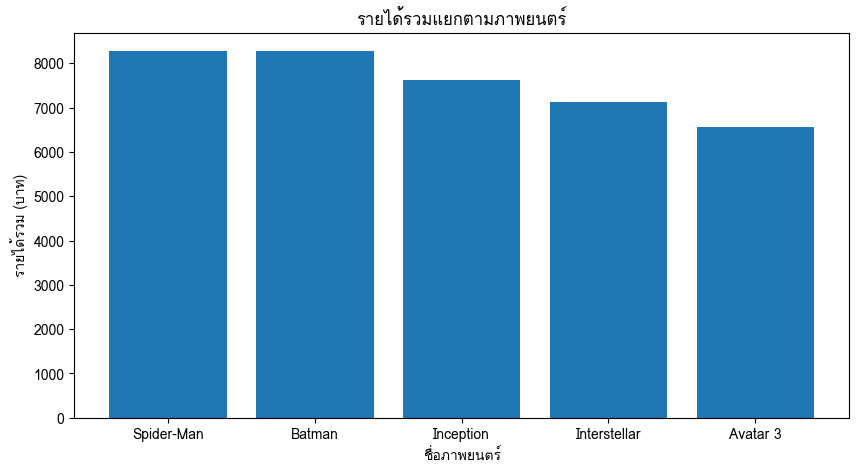

In [34]:
#ภาพยนตร์เรื่องไหนทำรายได้รวมมากที่สุด
import matplotlib.pyplot as plt
import pandas as pd
df=pd.read_csv("https://raw.githubusercontent.com/natthamonsmn/Cinema_Team/refs/heads/main/joined.csv")
# 1. กรองเฉพาะรายการที่ชำระเงินสำเร็จ (Paid)
paid_df = df[df["status"] == "Paid"]

# 2. รวมรายได้ตามชื่อภาพยนตร์ และเรียงลำดับจากมากไปน้อย
top_revenue_movie = (
    paid_df.groupby("movie_name")["price"]
    .sum()
    .sort_values(ascending=False)
  )
print(top_revenue_movie)
plt.figure(figsize=(10, 5))
plt.bar(top_revenue_movie.index, top_revenue_movie.values)
plt.title("รายได้รวมแยกตามภาพยนตร์")
plt.xlabel("ชื่อภาพยนตร์")
plt.ylabel("รายได้รวม (บาท)")
plt.show()

movie_name
Avatar 3        36
Batman          36
Inception       36
Spider-Man      36
Interstellar    31
dtype: int64


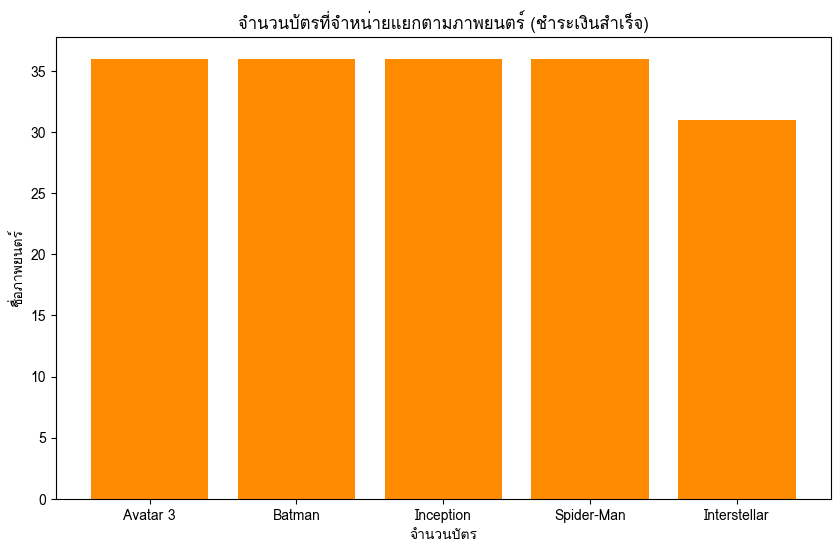

In [35]:
#จำนวนบัตรที่จำหน่ายแยกตามภาพยนตร์(ชำระเงินสำเร็จ)
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv("https://raw.githubusercontent.com/natthamonsmn/Cinema_Team/refs/heads/main/joined.csv")

# กรองเฉพาะรายการที่ชำระเงินสำเร็จ (Paid) และนับจำนวนตั๋วแยกตามภาพยนตร์
tickets_by_movie = (
    df[df["status"] == "Paid"]
    .groupby("movie_name")
    .size().sort_values(ascending=False)
    )
print(tickets_by_movie)
plt.figure(figsize=(10, 6))
bars = plt.bar(tickets_by_movie.index, tickets_by_movie.values, color="darkorange")
plt.title("จำนวนบัตรที่จำหน่ายแยกตามภาพยนตร์ (ชำระเงินสำเร็จ)")
plt.xlabel("จำนวนบัตร")
plt.ylabel("ชื่อภาพยนตร์")
plt.show()

seat_type
VIP          191.263158
Honeymoon    132.717949
Deluxe       100.500000
Normal        77.432432
Name: price, dtype: float64


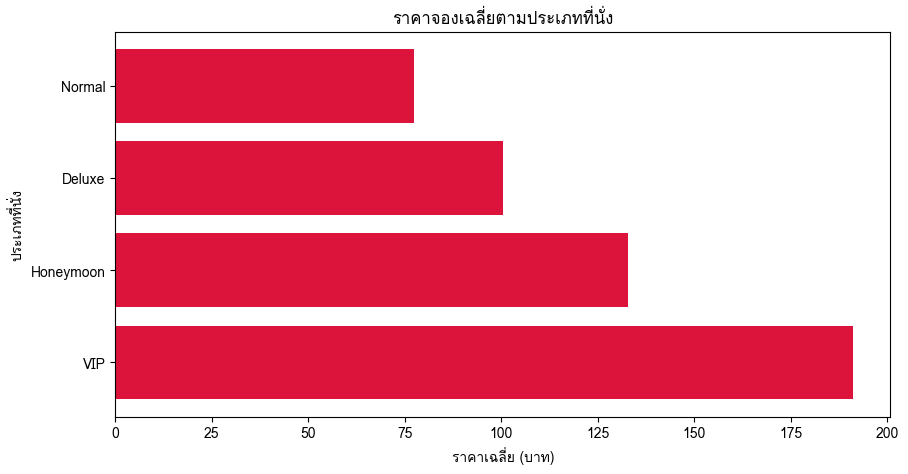

In [31]:
#ราคาจองเฉลี่ยตามประเภทที่นั่ง
import pandas as pd
df=pd.read_csv("https://raw.githubusercontent.com/natthamonsmn/Cinema_Team/refs/heads/main/joined.csv")
avg_price_by_seat = (df.groupby("seat_type")["price"].mean().sort_values(ascending=False))
print(avg_price_by_seat)
plt.figure(figsize=(10, 5))
plt.barh(avg_price_by_seat.index, avg_price_by_seat.values, color="crimson")
plt.title("ราคาจองเฉลี่ยตามประเภทที่นั่ง")
plt.xlabel("ราคาเฉลี่ย (บาท)")
plt.ylabel("ประเภทที่นั่ง")
plt.show()

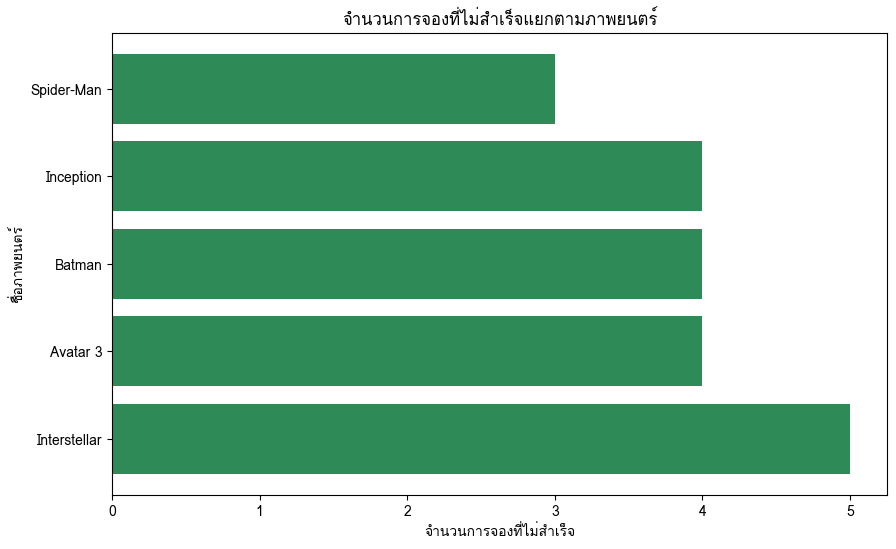

In [32]:
#การยกเลิกตั๋วหรือรายการที่ถูกปฏิเสธ
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv("https://raw.githubusercontent.com/natthamonsmn/Cinema_Team/refs/heads/main/joined.csv")
#  กรองเฉพาะรายการ Cancelled และ Rejected แล้วนับจำนวนแยกตามภาพยนตร์
failed_by_movie = (
    df[df["status"].isin(["Cancelled", "Rejected"])]
    .groupby("movie_name")
    .size()
    .sort_values(ascending=False)
)
plt.figure(figsize=(10, 6))
bars = plt.barh(failed_by_movie.index, failed_by_movie.values, color="seagreen")

plt.title("จำนวนการจองที่ไม่สำเร็จแยกตามภาพยนตร์")
plt.xlabel("จำนวนการจองที่ไม่สำเร็จ")
plt.ylabel("ชื่อภาพยนตร์")
plt.show()

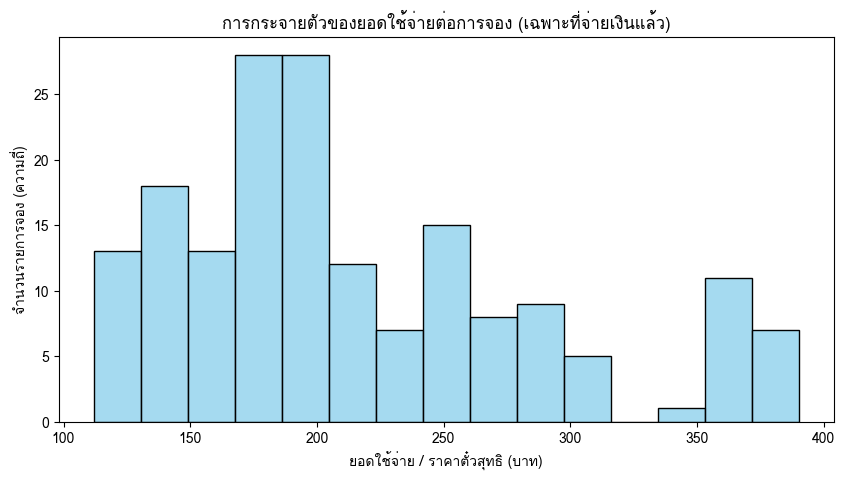

In [33]:
#การกระจายตัวของยอดใช้จ่ายต่อการจอง
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# โหลดข้อมูลและกรองเฉพาะรายการที่ชำระเงินสำเร็จ (Paid)
paid_bookings = df[df["status"] == "Paid"]
spending = paid_bookings["price"]

plt.figure(figsize=(10, 5))
sns.histplot(spending,bins=15, color='skyblue')

plt.title("การกระจายตัวของยอดใช้จ่ายต่อการจอง (เฉพาะที่จ่ายเงินแล้ว)")
plt.xlabel("ยอดใช้จ่าย / ราคาตั๋วสุทธิ (บาท)")
plt.ylabel("จำนวนรายการจอง (ความถี่)")
plt.show()